In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading the dataset
df = pd.read_csv("zomato.csv", encoding='latin-1')

In [3]:
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [4]:
# Checking how many rows and columns in our dataset
print("Shape of dataset:", df.shape)
print("Total Rows:", df.shape[0])
print("Total Columns:", df.shape[1])

Shape of dataset: (51717, 17)
Total Rows: 51717
Total Columns: 17


In [5]:
# Viewing all column names present in our dataset
print("Column Names:")
print(df.columns.tolist())

Column Names:
['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)']


In [6]:
# Checking datatypes of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [7]:
# check missing values
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [8]:
# check missing values in percentage
round((df.isnull().sum() / len(df)) * 100,2)

url                             0.00
address                         0.00
name                            0.00
online_order                    0.00
book_table                      0.00
rate                           15.03
votes                           0.00
phone                           2.34
location                        0.04
rest_type                       0.44
dish_liked                     54.29
cuisines                        0.09
approx_cost(for two people)     0.67
reviews_list                    0.00
menu_item                       0.00
listed_in(type)                 0.00
listed_in(city)                 0.00
dtype: float64

In [9]:
df.describe()

,votes
count,51717.000000
mean,283.697527
std,803.838853
min,0.000000
25%,7.000000
50%,41.000000
75%,198.000000
max,16832.000000


In [10]:
#check unique values in important columns
print("Online Order Categories:", df['online_order'].unique())
print("Book Table Categories:", df['book_table'].unique())
print("Total unique locations:", df['location'].nunique())
print("Total unique restaurant types:", df['rest_type'].nunique())
print("Total unique cuisines:", df['cuisines'].nunique())

Online Order Categories: ['Yes' 'No']
Book Table Categories: ['Yes' 'No']
Total unique locations: 93
Total unique restaurant types: 93
Total unique cuisines: 2723


#DATA CLEANING

DROP DUPLIACTE ROWS

In [11]:
#Removing dupliactes rowws if any
df.drop_duplicates(inplace=True)

print("Dupliactes removed!")
print("New Shape:", df.shape)

Dupliactes removed!
New Shape: (51717, 17)


In [12]:
# Dropping columns that are not useful for our analysis
df = df.drop(['url', 'address', 'phone','reviews_list', 'menu_item'], axis = 1)

print("Unnecessary columns dropped!")
print("Remaining columns:", df.columns.tolist())

Unnecessary columns dropped!
Remaining columns: ['name', 'online_order', 'book_table', 'rate', 'votes', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'listed_in(type)', 'listed_in(city)']


In [13]:
#rate column has values like "4.1/5" -- we need just the umber 4.1
#Step1: Remove "/5" from the values
df['rate'] = df['rate'].astype(str).str.replace('/5', '', regex = False)
#Step 2: Replace "NEW" to "-" with NaN(missing value)
df['rate'] = df['rate'].replace(['NEW', '-', 'nan'], np.nan)
#Step 3: Convert to float(decimal number)
df['rate'] = df['rate'].astype(float)

print("Rate column cleaned!")
print(df['rate'].head(10))

Rate column cleaned!
0    4.1
1    4.1
2    3.8
3    3.7
4    3.8
5    3.8
6    3.6
7    4.6
8    4.0
9    4.2
Name: rate, dtype: float64


CLEAN THE APPROX_COST COLUMN

In [14]:
#approx_cost has values lilke"1,200" --- comma needs to be removed
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str).str.replace(',', '', regex=False)
#Convert to float
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')

print("Cost column cleaned!")
print(df['approx_cost(for two people)'].head(10))

Cost column cleaned!
0    800.0
1    800.0
2    800.0
3    300.0
4    600.0
5    600.0
6    800.0
7    600.0
8    700.0
9    550.0
Name: approx_cost(for two people), dtype: float64


RENAME THE LONG COLUMN NAME

In [15]:
#Renaming long column name to shorter and easier
df = df.rename(columns={'approx_cost(for two people)': 'cost_for_two'})

print('Column renamed!')
print(df.columns.tolist())

Column renamed!
['name', 'online_order', 'book_table', 'rate', 'votes', 'location', 'rest_type', 'dish_liked', 'cuisines', 'cost_for_two', 'listed_in(type)', 'listed_in(city)']


In [16]:
#Check data types after cleaning
print(df.dtypes)
print("\nFirst 5 rows after cleaning:")
df.head()

name                object
online_order        object
book_table          object
rate               float64
votes                int64
location            object
rest_type           object
dish_liked          object
cuisines            object
cost_for_two       float64
listed_in(type)     object
listed_in(city)     object
dtype: object

First 5 rows after cleaning:


,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,cost_for_two,listed_in(type),listed_in(city)
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800.0,Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300.0,Buffet,Banashankari
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600.0,Buffet,Banashankari


HANDLING VALUES

In [17]:
#Checking missing values after cleaning
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
name                   0
online_order           0
book_table             0
rate               10052
votes                  0
location              21
rest_type            227
dish_liked         28078
cuisines              45
cost_for_two         346
listed_in(type)        0
listed_in(city)        0
dtype: int64


In [18]:
#Dropping rowws when rate is missing
#We can't fill arting with a guess -- it's our most important column
df.dropna(subset=['rate'], inplace=True)

print("Rows with missing rate dropped!")
print("New shape:", df.shape)

Rows with missing rate dropped!
New shape: (41665, 12)


# Fill missing values in cost_for_two

In [19]:
#Filling missing cost values with the median cost
median_cost = df['cost_for_two'].median()
df['cost_for_two'].fillna(median_cost, inplace=True)

print("Missing cost values filled with median:", median_cost)

Missing cost values filled with median: 500.0


C:\Users\Acer\AppData\Local\Temp\ipykernel_6216\2424930609.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['cost_for_two'].fillna(median_cost, inplace=True)


In [20]:
# Filling missing rest_type with the most common type
common_rest_type = df['rest_type'].mode()[0]
df['rest_type'].fillna(common_rest_type, inplace=True)

print("Missing rest_type filled with:", common_rest_type)

Missing rest_type filled with: Quick Bites


C:\Users\Acer\AppData\Local\Temp\ipykernel_6216\2591153541.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rest_type'].fillna(common_rest_type, inplace=True)


In [21]:
#Filling missing cuisines with "Unknown"
df['cuisines'].fillna("Unknown", inplace=True)

print("Missing cuisines filled with Unknown!")

Missing cuisines filled with Unknown!


C:\Users\Acer\AppData\Local\Temp\ipykernel_6216\1103195023.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['cuisines'].fillna("Unknown", inplace=True)


Drop dish_liked column

In [22]:
#dish_liked has too many missing values -- over 50% missing
#Its better to drop it entirely
df = df.drop(['dish_liked'], axis=1)

print("dish_liked column dropped!")
print("Remaining columns:", df.columns.tolist())

dish_liked column dropped!
Remaining columns: ['name', 'online_order', 'book_table', 'rate', 'votes', 'location', 'rest_type', 'cuisines', 'cost_for_two', 'listed_in(type)', 'listed_in(city)']


In [23]:
# Check if any missing values remain
print("Remaining missing values:")
print(df.isnull().sum())
print("\nFinal shape of dataset:", df.shape)

Remaining missing values:
name               0
online_order       0
book_table         0
rate               0
votes              0
location           0
rest_type          0
cuisines           0
cost_for_two       0
listed_in(type)    0
listed_in(city)    0
dtype: int64

Final shape of dataset: (41665, 11)


In [24]:
#Resetting index after dropping rows
df.reset_index(drop=True, inplace=True)

print("Index reset successfully!")
df.head()

Index reset successfully!


,name,online_order,book_table,rate,votes,location,rest_type,cuisines,cost_for_two,listed_in(type),listed_in(city)
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0,Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800.0,Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,Buffet,Banashankari
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,Buffet,Banashankari


Exploratory Data Analysis

In [25]:
#Basic  statistics of numeric columns
df.describe()

,rate,votes,cost_for_two
count,41665.000000,41665.000000,41665.000000
mean,3.700449,351.653018,602.655850
std,0.440513,881.800960,463.017327
min,1.800000,0.000000,40.000000
25%,3.400000,21.000000,300.000000
50%,3.700000,73.000000,500.000000
75%,4.000000,276.000000,700.000000
max,4.900000,16832.000000,6000.000000


In [26]:
#Average rating of all restaurants
avg_rating = df['rate'].mean()
print("Average Rating:", round(avg_rating,2))

Average Rating: 3.7


In [27]:
#online order distribution
#How many restaurants offer online ordering or not?
print("Online Order Distribution:")
print(df['online_order'].value_counts())
print("\nPercentage")
print(round(df['online_order'].value_counts(normalize=True) *100, 2))

Online Order Distribution:
online_order
Yes    27206
No     14459
Name: count, dtype: int64

Percentage
online_order
Yes    65.3
No     34.7
Name: proportion, dtype: float64


In [28]:
# How many restaurants offer table bboking ?
print("Book Table Distribution:")
print(df['book_table'].value_counts())
print("\nPercentage")
print(round(df['book_table'].value_counts(normalize=True) *100, 2))

Book Table Distribution:
book_table
No     35361
Yes     6304
Name: count, dtype: int64

Percentage
book_table
No     84.87
Yes    15.13
Name: proportion, dtype: float64


In [29]:
#Do restaurants with online ordering have better ratings?
print("Average Rating by Online Order:")
print(df.groupby('online_order')['rate'].mean().round(2))

Average Rating by Online Order:
online_order
No     3.66
Yes    3.72
Name: rate, dtype: float64


In [30]:
#Do restaurants with table booking have better restaurants?
print("Average Rating by Book Table:")
print(df.groupby('book_table')['rate'].mean().round(2))

Average Rating by Book Table:
book_table
No     3.62
Yes    4.14
Name: rate, dtype: float64


In [31]:
#Which areas in bangalore have the most restaurants?
print("Top 10 locations:")
print(df['location'].value_counts().head(10))

Top 10 locations:
location
BTM                      3930
Koramangala 5th Block    2319
HSR                      2019
Indiranagar              1847
JP Nagar                 1717
Jayanagar                1643
Whitefield               1582
Marathahalli             1443
Bannerghatta Road        1235
Koramangala 6th Block    1077
Name: count, dtype: int64


In [33]:
#What types of restaurants are most common?
print("Top 10 Restaurant types:")
print(df['rest_type'].value_counts().head(10))

Top 10 Restaurant types:
rest_type
Quick Bites           14093
Casual Dining          9659
Cafe                   3405
Dessert Parlor         1864
Delivery               1680
Takeaway, Delivery     1292
Casual Dining, Bar     1110
Bakery                  704
Bar                     651
Beverage Shop           642
Name: count, dtype: int64


In [48]:
#What cuisines are most common?
print("Top 10 Cuisines:")
print(df['cuisines'].value_counts().head(10))

Top 10 Cuisines:
cuisines
North Indian                           2158
North Indian, Chinese                  1980
South Indian                           1234
Cafe                                    642
Bakery, Desserts                        615
Biryani                                 609
South Indian, North Indian, Chinese     561
Desserts                                551
Fast Food                               517
Chinese                                 410
Name: count, dtype: int64


In [50]:
# What is the average cost for two people?
print("Average Cost forTwo:", round(df['cost_for_two'].mean(),2))
print("Minimum Cost:", df['cost_for_two'].min())
print("Maximum COst:", df['cost_for_two'].max())

Average Cost forTwo: 602.66
Minimum Cost: 40.0
Maximum COst: 6000.0


In [51]:
#Do expensive restaurants have better ratings?
print("Correlation between Cost and Rating:")
print(round(df[['rate', 'cost_for_two']].corr(),2))

Correlation between Cost and Rating:
              rate  cost_for_two
rate          1.00          0.38
cost_for_two  0.38          1.00


DATA VISULALIZATION

In [34]:
#Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] =(10,6)

In [35]:
import os
os.makedirs('images',exist_ok=True)
print("Images folder created!")

Images folder created!


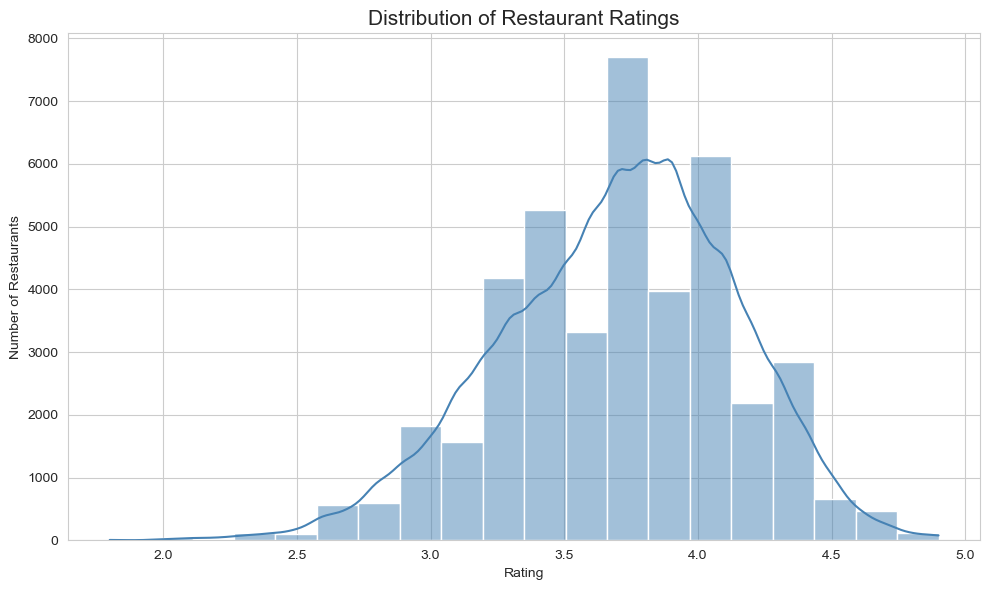

In [36]:
#Distribution of ratings
plt.figure(figsize=(10,6))
sns.histplot(df['rate'], bins = 20, kde=True, color='steelblue')
plt.title('Distribution of Restaurant Ratings', fontsize=15)
plt.xlabel('Rating')
plt.ylabel('Number of Restaurants')
plt.tight_layout()
plt.savefig('images/rating_distribution.png')
plt.show()

C:\Users\Acer\AppData\Local\Temp\ipykernel_6216\742607441.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='online_order', y='rate', data=df, palette='Set2')


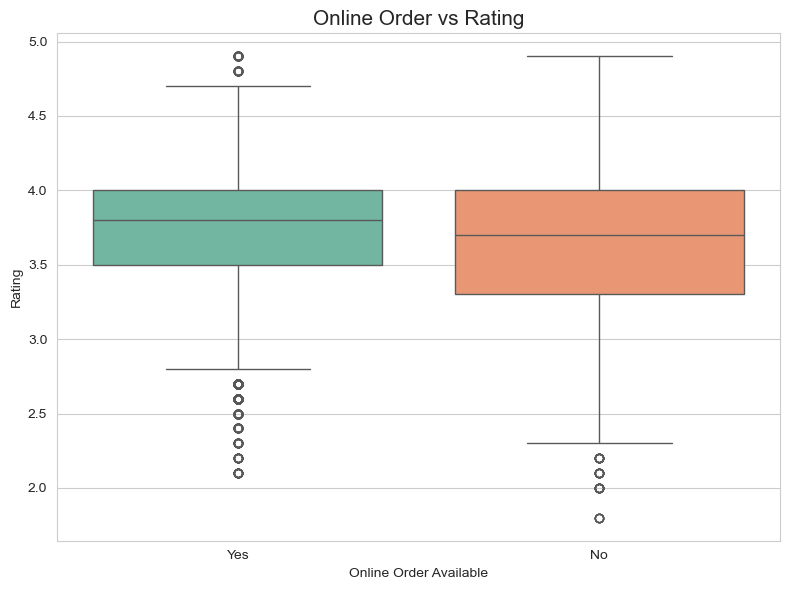

In [38]:
#Online order vs rating
plt.figure(figsize=(8,6))
sns.boxplot(x='online_order', y='rate', data=df, palette='Set2')
plt.title('Online Order vs Rating', fontsize=15)
plt.xlabel('Online Order Available')
plt.ylabel('Rating')
plt.tight_layout()
plt.savefig('images/online_order_vs_rating.png')
plt.show()

C:\Users\Acer\AppData\Local\Temp\ipykernel_6216\538716789.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='book_table', y='rate', data=df, palette='Set3')


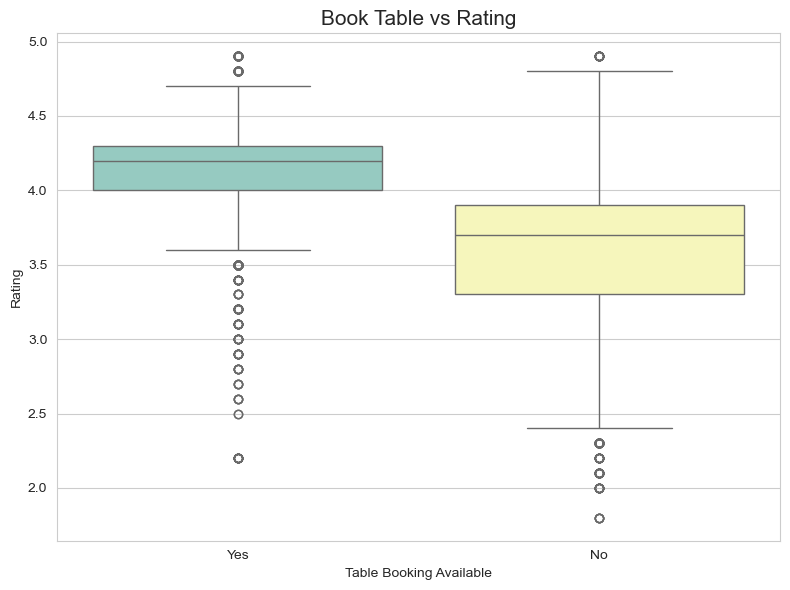

In [39]:
#Book table vs Rating
plt.figure(figsize=(8,6))
sns.boxplot(x='book_table', y='rate', data=df, palette='Set3')
plt.title('Book Table vs Rating', fontsize = 15)
plt.xlabel('Table Booking Available')
plt.ylabel('Rating')
plt.tight_layout()
plt.savefig('images/book_table_vs_rating.png')
plt.show()

C:\Users\Acer\AppData\Local\Temp\ipykernel_6216\3038598174.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_locations.values, y=top_locations.index, palette='viridis')


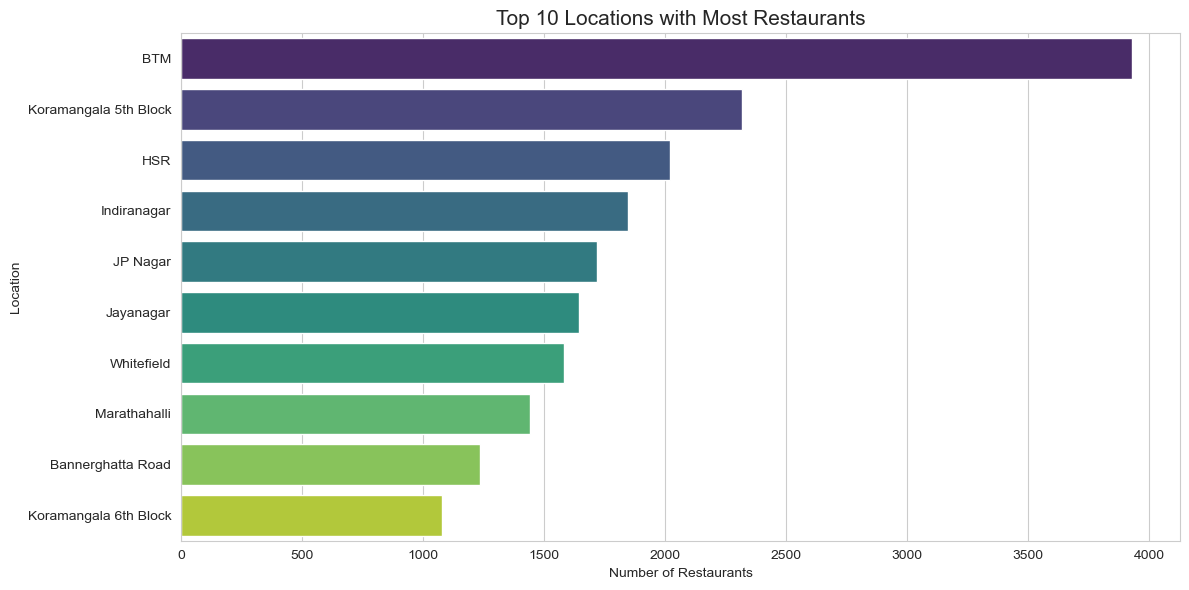

In [41]:
#Top 10 locations
top_locations = df['location'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_locations.values, y=top_locations.index, palette='viridis')
plt.title('Top 10 Locations with Most Restaurants', fontsize=15)
plt.xlabel('Number of Restaurants')
plt.ylabel('Location')
plt.tight_layout()
plt.savefig('images/top_locations.png')
plt.show()


C:\Users\Acer\AppData\Local\Temp\ipykernel_6216\2810927427.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_rest_types.values, y=top_rest_types.index, palette='magma')


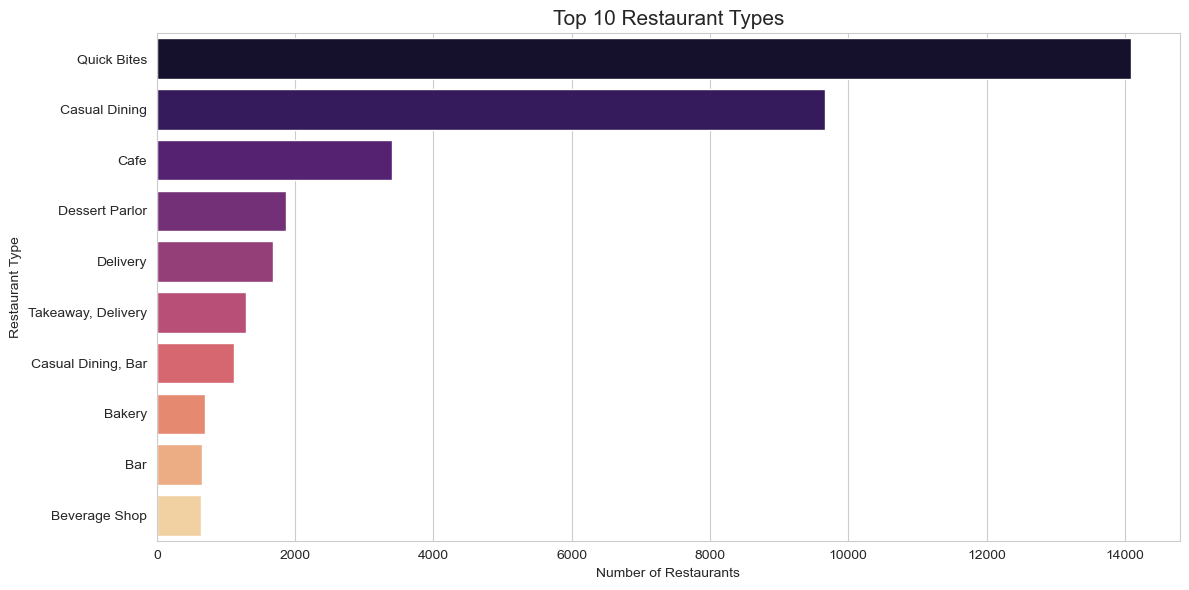

In [46]:
#Top 10 Restaurant types
top_rest_types = df['rest_type'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_rest_types.values, y=top_rest_types.index, palette='magma')
plt.title('Top 10 Restaurant Types', fontsize=15)
plt.xlabel('Number of Restaurants')
plt.ylabel('Restaurant Type')
plt.tight_layout()
plt.savefig('images/top_rest_types.png')
plt.show()

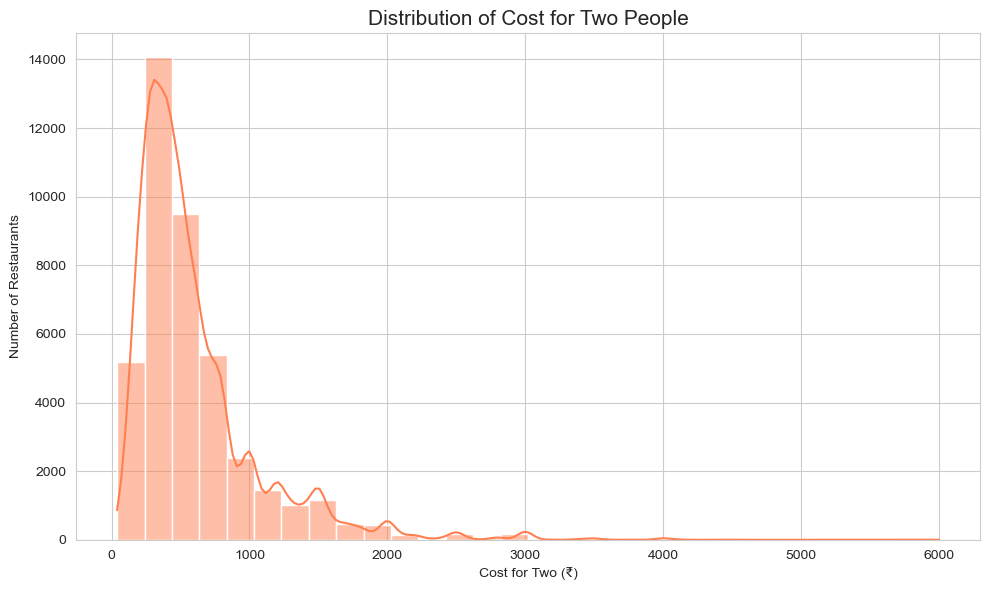

In [45]:
#Cost distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['cost_for_two'], bins=30, kde=True, color='coral')
plt.title('Distribution of Cost for Two People', fontsize=15)
plt.xlabel('Cost for Two (₹)')
plt.ylabel('Number of Restaurants')
plt.tight_layout()
plt.savefig('images/cost_distribution.png')
plt.show()

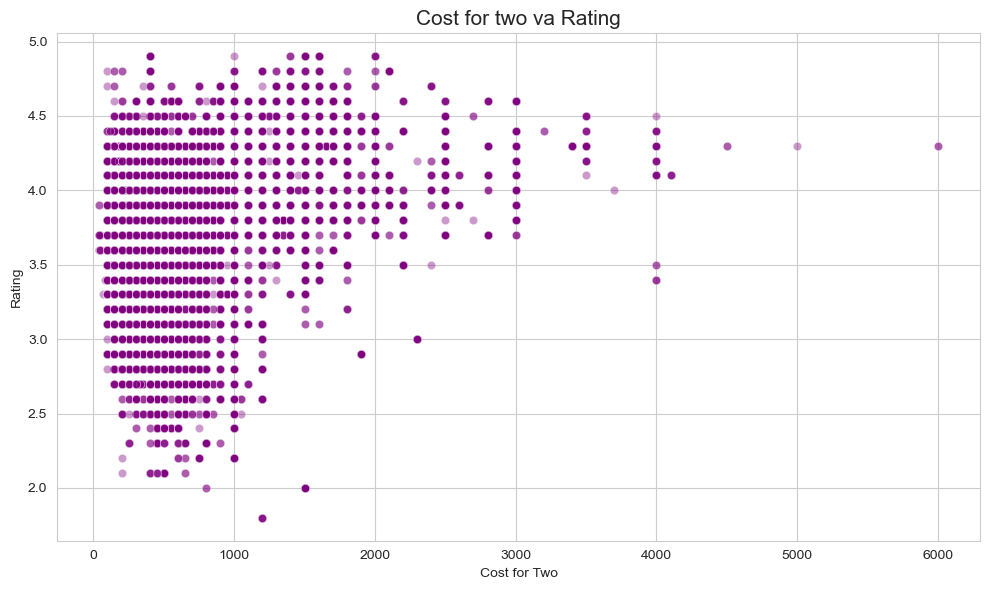

In [47]:
#cost vs rating
plt.figure(figsize=(10,6))
sns.scatterplot(x='cost_for_two', y='rate', data=df, alpha=0.4, color='purple')
plt.title('Cost for two va Rating', fontsize=15)
plt.xlabel('Cost for Two')
plt.ylabel('Rating')
plt.tight_layout()
plt.savefig('images/cost_vs_rating.png')
plt.show()

C:\Users\Acer\AppData\Local\Temp\ipykernel_6216\1918062649.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cuisines.values, y=top_cuisines.index, palette='coolwarm')


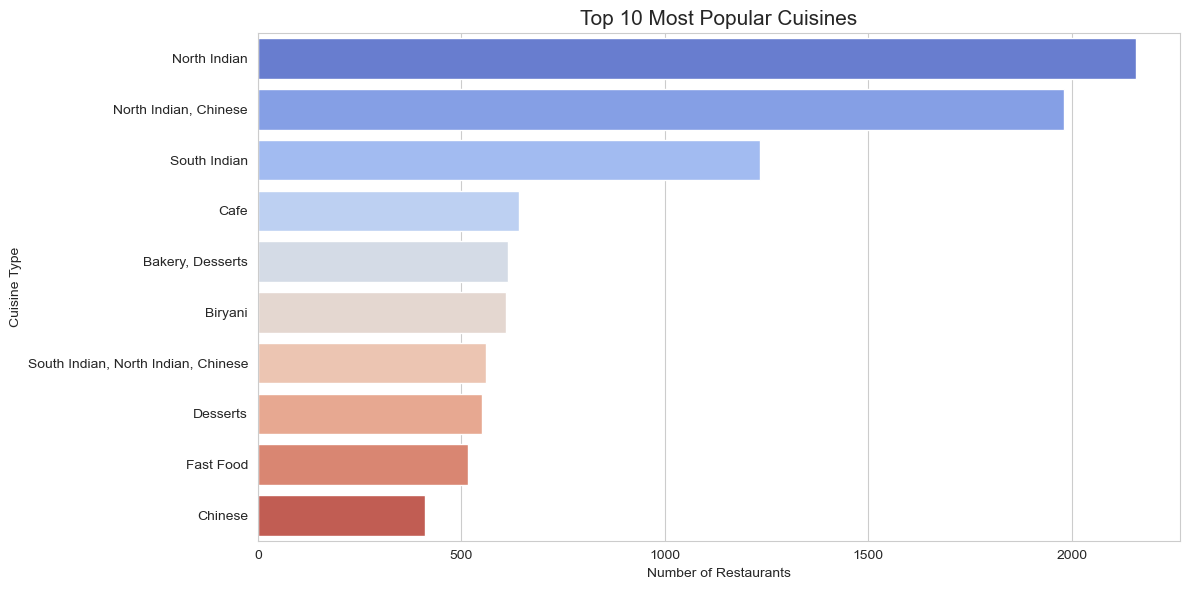

In [48]:
#Top 10 cuisines
top_cuisines = df['cuisines'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index, palette='coolwarm')
plt.title('Top 10 Most Popular Cuisines', fontsize=15)
plt.xlabel('Number of Restaurants')
plt.ylabel('Cuisine Type')
plt.tight_layout()
plt.savefig('images/top_cuisines.png')
plt.show()

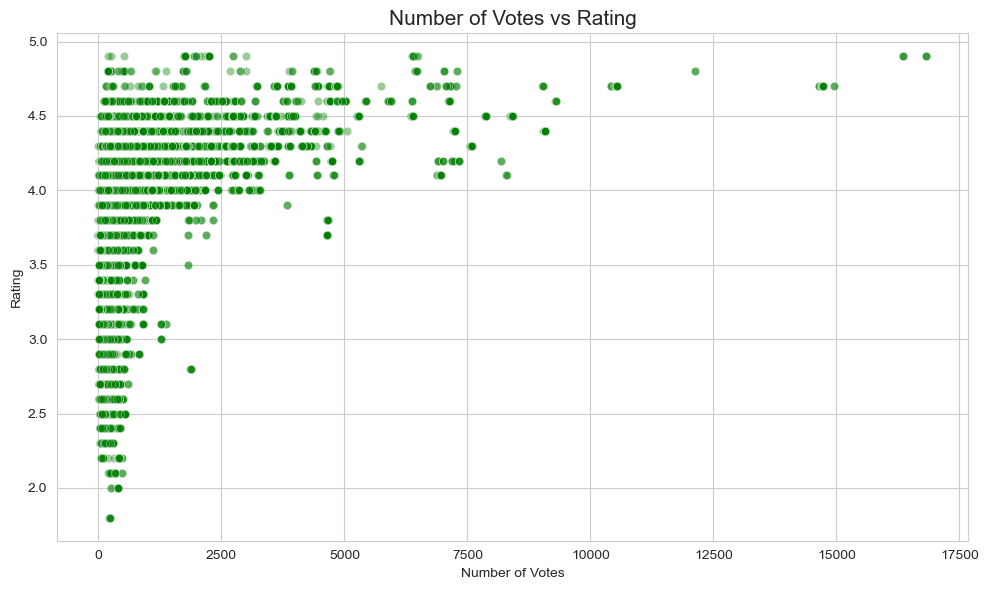

In [49]:
#Vote vs Rating
plt.figure(figsize=(10, 6))
sns.scatterplot(x='votes', y='rate', data=df, alpha=0.4, color='green')
plt.title('Number of Votes vs Rating', fontsize=15)
plt.xlabel('Number of Votes')
plt.ylabel('Rating')
plt.tight_layout()
plt.savefig('images/votes_vs_rating.png')
plt.show()

Statistical Analysis and Correlations

In [53]:
# Correlation between all numeric columns
correlation = df[['rate', 'votes', 'cost_for_two']].corr()
print("Correlation Matrix:")
print(correlation)

Correlation Matrix:
                  rate     votes  cost_for_two
rate          1.000000  0.434040      0.384042
votes         0.434040  1.000000      0.365949
cost_for_two  0.384042  0.365949      1.000000


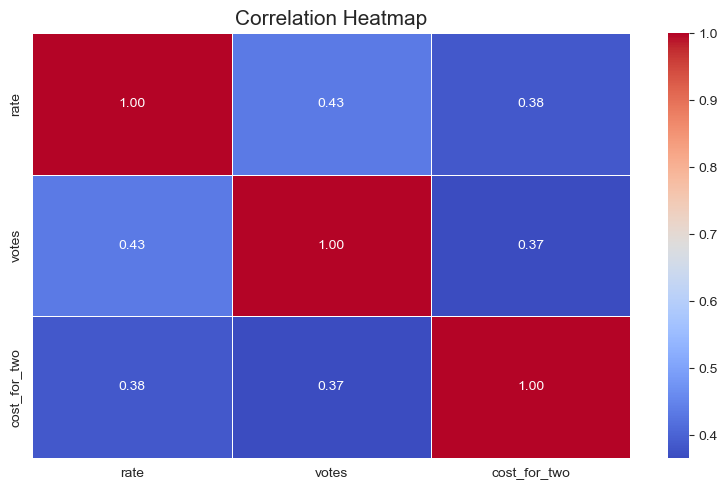

In [57]:
#Visualizing correaltion as a heatmap
plt.figure(figsize=(8,5))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=15)
plt.tight_layout()
plt.savefig('images/correlation_heatmap.png')
plt.show()

C:\Users\Acer\AppData\Local\Temp\ipykernel_6216\619629263.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=location_rating.values, y=location_rating.index, palette='viridis')


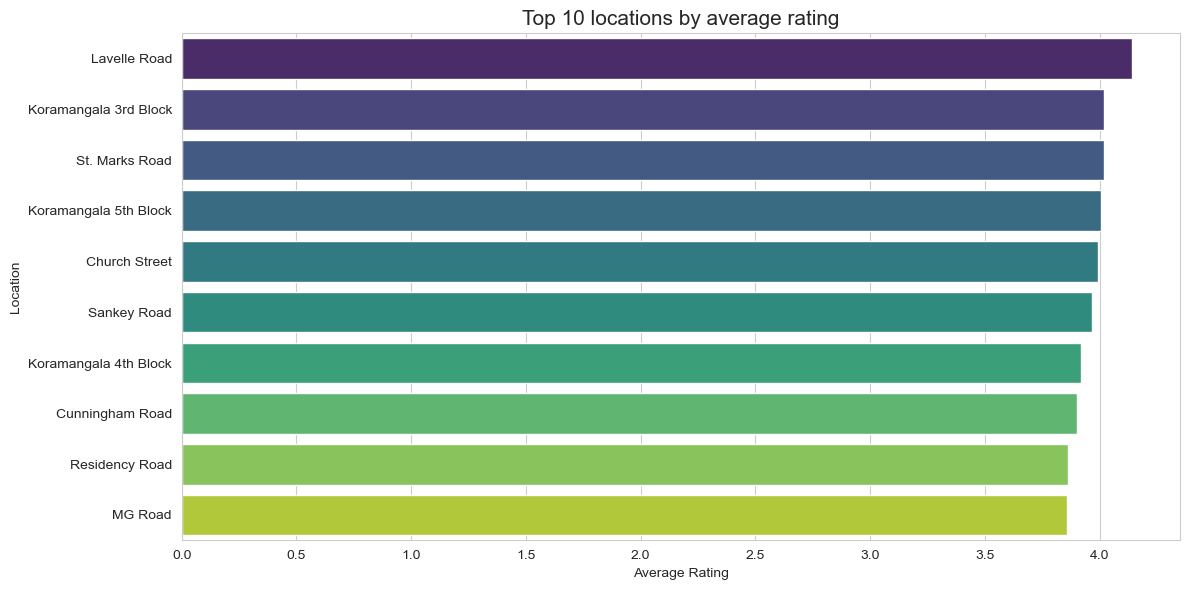

In [60]:
#Which locations have the highest average ratings?
location_rating = df.groupby('location')['rate'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=location_rating.values, y=location_rating.index, palette='viridis')
plt.title('Top 10 locations by average rating', fontsize=15)
plt.xlabel('Average Rating')
plt.ylabel('Location')
plt.tight_layout()
plt.savefig('images/location_vs_rating.png')
plt.show()

C:\Users\Acer\AppData\Local\Temp\ipykernel_6216\2831944141.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rest_type_rating.values, y=rest_type_rating.index, palette='magma')


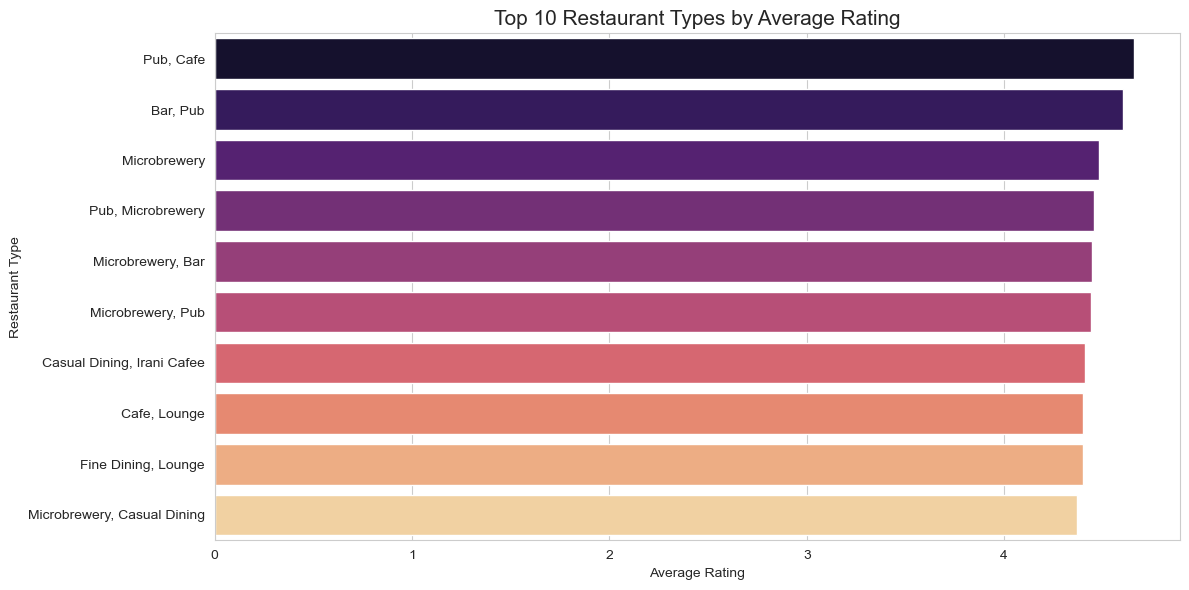

In [61]:
# which restaurant types have highesta verage ratings?
# Which restaurant types have highest average ratings?
rest_type_rating = df.groupby('rest_type')['rate'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=rest_type_rating.values, y=rest_type_rating.index, palette='magma')
plt.title('Top 10 Restaurant Types by Average Rating', fontsize=15)
plt.xlabel('Average Rating')
plt.ylabel('Restaurant Type')
plt.tight_layout()
plt.savefig('images/rest_type_vs_rating.png')
plt.show()

C:\Users\Acer\AppData\Local\Temp\ipykernel_6216\3012001589.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=location_cost.values, y=location_cost.index, palette='coolwarm')


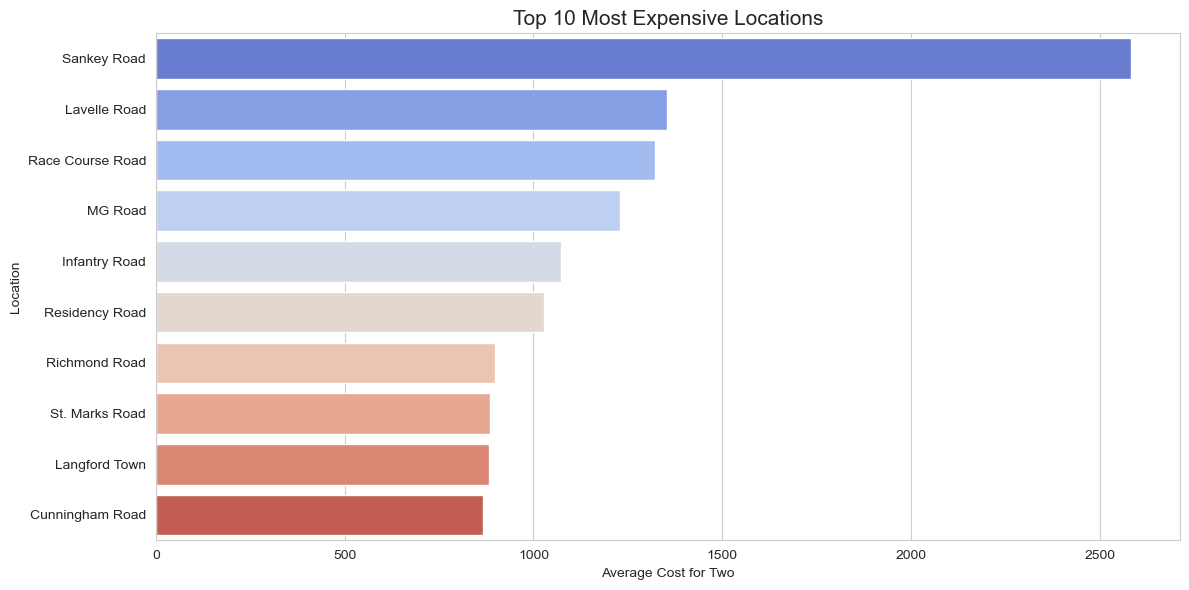

In [63]:
#which locations are most expensive on avergae?
location_cost = df.groupby('location')['cost_for_two'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=location_cost.values, y=location_cost.index, palette='coolwarm')
plt.title('Top 10 Most Expensive Locations', fontsize=15)
plt.xlabel('Average Cost for Two')
plt.ylabel('Location')
plt.tight_layout()
plt.savefig('images/location_vs_cost.png')
plt.show()

In [65]:
# Do restaurants with online ordering tend to br cheaper or more expensive?
print("Average cost by Online Order:")
print(df.groupby('online_order')['cost_for_two'].mean().round(2))

Average cost by Online Order:
online_order
No     712.33
Yes    544.37
Name: cost_for_two, dtype: float64


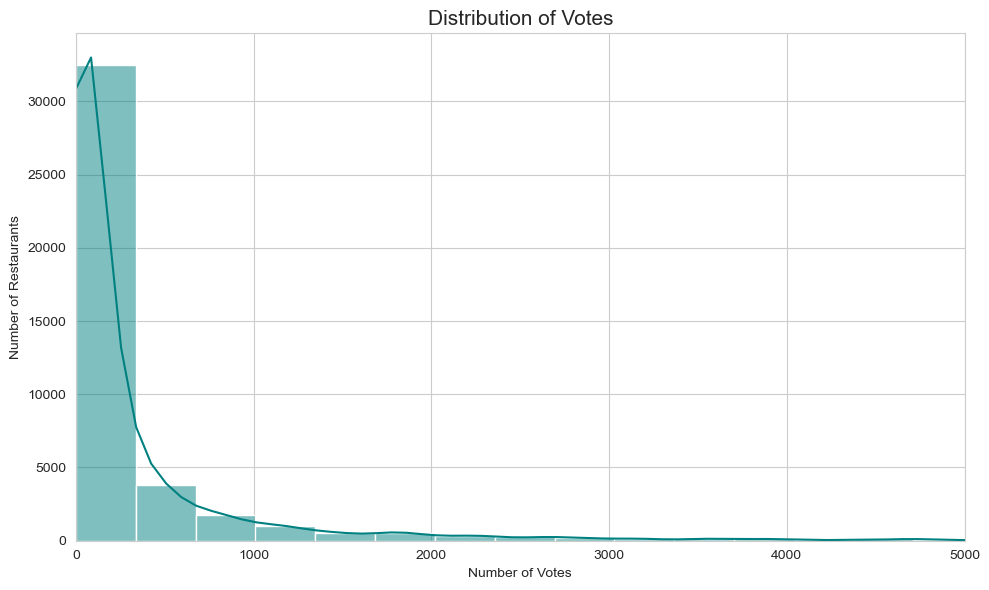

In [66]:
#Distribution of votes
# Distribution of votes
plt.figure(figsize=(10, 6))
sns.histplot(df['votes'], bins=50, kde=True, color='teal')
plt.title('Distribution of Votes', fontsize=15)
plt.xlabel('Number of Votes')
plt.ylabel('Number of Restaurants')
plt.xlim(0, 5000)  # limiting x axis for better visibility
plt.tight_layout()
plt.savefig('images/votes_distribution.png')
plt.show()

In [67]:
#Complete summary of ratings grouped by online order
# Complete summary of ratings grouped by online order
print("Summary Statistics by Online Order:")
print(df.groupby('online_order')['rate'].describe().round(2))

Summary Statistics by Online Order:
                count  mean   std  min  25%  50%  75%  max
online_order                                              
No            14459.0  3.66  0.47  1.8  3.3  3.7  4.0  4.9
Yes           27206.0  3.72  0.42  2.1  3.5  3.8  4.0  4.9


FEATURE ENGINEERING

In [68]:
#Create Cost Category Column
def cost_category(cost):
    if cost <= 300:
        return 'Budget'
    elif cost <= 600:
        return 'Mid Range'
    elif cost <=1000:
        return 'Premium'
    else:
        return 'Luxury'

df['cost_category'] = df['cost_for_two'].apply(cost_category)

print("Cost Category column created!")
print(df['cost_category'].value_counts())
        
        

Cost Category column created!
cost_category
Mid Range    16153
Budget       12587
Premium       7790
Luxury        5135
Name: count, dtype: int64


In [69]:
# create rating category column
def rating_category(rate):
    if rate >= 4.5:
        return 'Excellent'
    elif rate >= 4.0:
        return 'Very Good'
    elif rate >= 3.5:
        return 'Good'
    elif rate >= 3.0:
        return 'Average'
    else: 
        return 'Below Average'

df['rating_category'] = df['rate'].apply(rating_category)

print("Rating Category column created!")
print(df['rating_category'].value_counts())
        

Rating Category column created!
rating_category
Good             17766
Very Good        11155
Average           9243
Below Average     2257
Excellent         1244
Name: count, dtype: int64


C:\Users\Acer\AppData\Local\Temp\ipykernel_6216\2252669529.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cost_category', data=df, order=cost_order, palette='viridis')


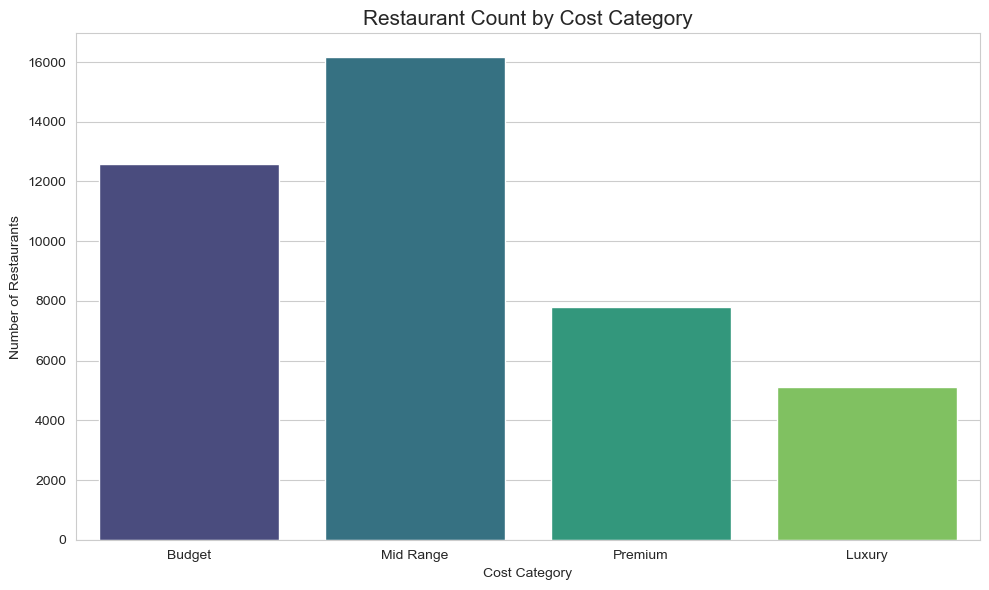

In [75]:
#Visualize cost categories

cost_order = ['Budget', 'Mid Range', 'Premium', 'Luxury']

plt.figure(figsize=(10,6))
sns.countplot(x='cost_category', data=df, order=cost_order, palette='viridis')
plt.title('Restaurant Count by Cost Category', fontsize = 15)
plt.xlabel('Cost Category')
plt.ylabel('Number of Restaurants')
plt.tight_layout()
plt.savefig('images/cost_category.png')
plt.show()

C:\Users\Acer\AppData\Local\Temp\ipykernel_6216\3371493171.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating_category', data=df, order=rating_order, palette='magma')


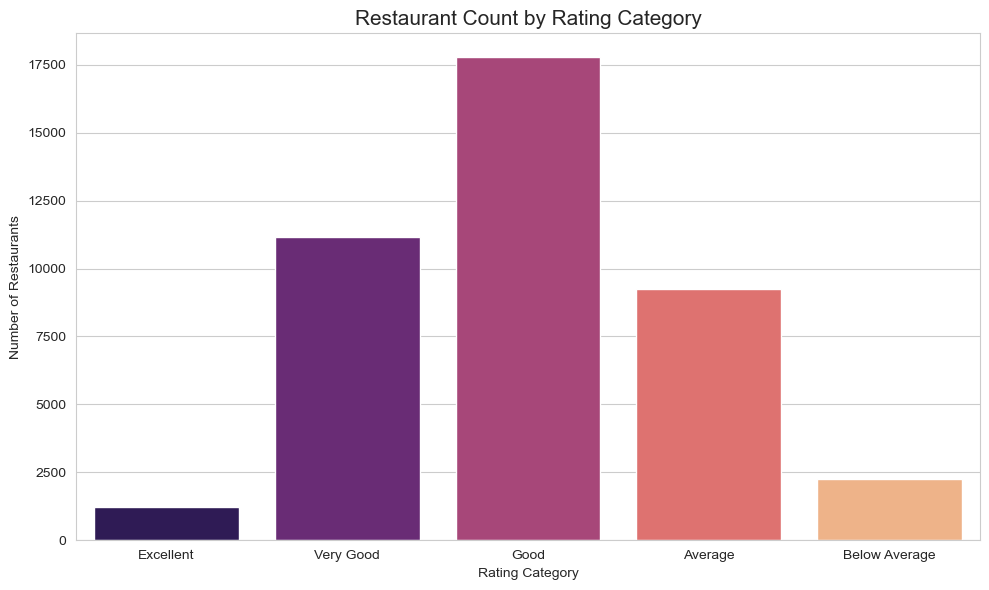

In [76]:
# Visualize rating categories
plt.figure(figsize=(10, 6))
rating_order = ['Excellent', 'Very Good', 'Good', 'Average', 'Below Average']
sns.countplot(x='rating_category', data=df, order=rating_order, palette='magma')
plt.title('Restaurant Count by Rating Category', fontsize=15)
plt.xlabel('Rating Category')
plt.ylabel('Number of Restaurants')
plt.tight_layout()
plt.savefig('images/rating_category.png')
plt.show()

Average Rating by Cost Category:
cost_category
Budget       3.57
Luxury       4.13
Mid Range    3.62
Premium      3.80
Name: rate, dtype: float64


C:\Users\Acer\AppData\Local\Temp\ipykernel_6216\1938052121.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cost_order, y=[cost_rating[c] for c in cost_order], palette='coolwarm')


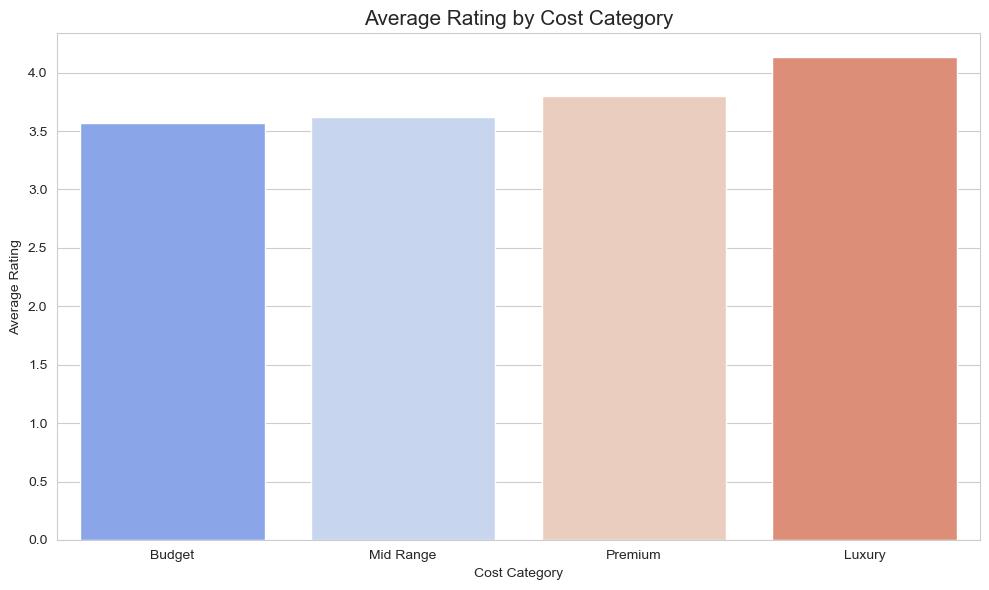

In [77]:
#cost category vs average rating
cost_rating = df.groupby('cost_category')['rate'].mean().round(2)
print("Average Rating by Cost Category:")
print(cost_rating)

plt.figure(figsize=(10, 6))
sns.barplot(x=cost_order, y=[cost_rating[c] for c in cost_order], palette='coolwarm')
plt.title('Average Rating by Cost Category', fontsize=15)
plt.xlabel('Cost Category')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.savefig('images/cost_category_vs_rating.png')
plt.show()

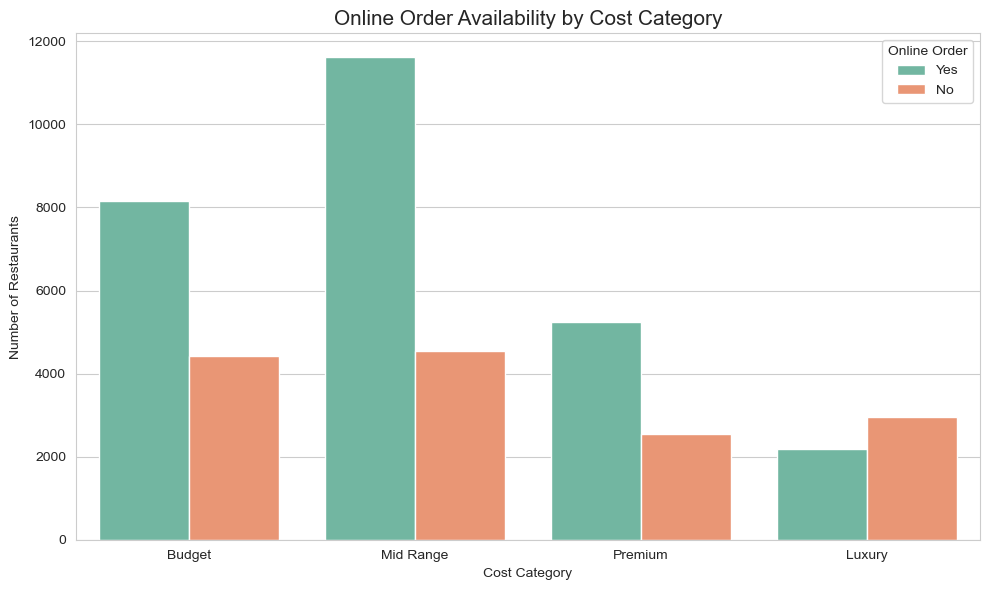

In [78]:
#Online order vs cost category
plt.figure(figsize=(10, 6))
sns.countplot(x='cost_category', hue='online_order', data=df, order=cost_order, palette='Set2')
plt.title('Online Order Availability by Cost Category', fontsize=15)
plt.xlabel('Cost Category')
plt.ylabel('Number of Restaurants')
plt.legend(title='Online Order')
plt.tight_layout()
plt.savefig('images/online_order_cost_category.png')
plt.show()

In [79]:
print("Final Shape:", df.shape)
print("\nNew Columns Added:")
print(df[['rate', 'rating_category', 'cost_for_two', 'cost_category']].head(10))

Final Shape: (41665, 13)

New Columns Added:
   rate rating_category  cost_for_two cost_category
0   4.1       Very Good         800.0       Premium
1   4.1       Very Good         800.0       Premium
2   3.8            Good         800.0       Premium
3   3.7            Good         300.0        Budget
4   3.8            Good         600.0     Mid Range
5   3.8            Good         600.0     Mid Range
6   3.6            Good         800.0       Premium
7   4.6       Excellent         600.0     Mid Range
8   4.0       Very Good         700.0       Premium
9   4.2       Very Good         550.0     Mid Range


KEY INSIGHTS AND BUSINESS RECOMMENDATIONS

In [80]:
print("""
=================================================
      KEY INSIGHTS - ZOMATO DATA ANALYSIS
=================================================

1. ONLINE ORDERING IMPACT:
   - Restaurants WITH online ordering have higher 
     average ratings than those without.
   - This suggests online ordering improves customer 
     satisfaction and reach.

2. TABLE BOOKING IMPACT:
   - Restaurants offering table booking have 
     significantly higher ratings.
   - These tend to be premium/fine dining places 
     that focus on quality experience.

3. COST VS RATING:
   - There is a positive correlation between cost 
     and rating.
   - More expensive restaurants tend to get 
     better ratings.

4. POPULAR LOCATIONS:
   - BTM, Koramangala and Indiranagar have the 
     highest number of restaurants.
   - These are the most competitive areas for 
     food businesses in Bangalore.

5. MOST EXPENSIVE LOCATIONS:
   - Sankey Road is the most expensive area 
     with average cost of ₹2500+ for two.
   - Lavelle Road and Race Course Road are 
     second and third most expensive.

6. POPULAR CUISINES:
   - North Indian and Chinese cuisines are 
     the most common in Bangalore.
   - These are the safest cuisine choices 
     for a new restaurant.

7. RESTAURANT TYPES:
   - Quick Bites and Casual Dining are the 
     most common restaurant types.
   - People prefer affordable casual dining 
     over fine dining options.

8. COST CATEGORIES:
   - Majority of restaurants fall in Budget 
     and Mid Range categories.
   - This shows Bangalore's food scene is 
     mostly affordable.

=================================================
""")


      KEY INSIGHTS - ZOMATO DATA ANALYSIS

1. ONLINE ORDERING IMPACT:
   - Restaurants WITH online ordering have higher 
     average ratings than those without.
   - This suggests online ordering improves customer 
     satisfaction and reach.

2. TABLE BOOKING IMPACT:
   - Restaurants offering table booking have 
     significantly higher ratings.
   - These tend to be premium/fine dining places 
     that focus on quality experience.

3. COST VS RATING:
   - There is a positive correlation between cost 
     and rating.
   - More expensive restaurants tend to get 
     better ratings.

4. POPULAR LOCATIONS:
   - BTM, Koramangala and Indiranagar have the 
     highest number of restaurants.
   - These are the most competitive areas for 
     food businesses in Bangalore.

5. MOST EXPENSIVE LOCATIONS:
   - Sankey Road is the most expensive area 
     with average cost of ₹2500+ for two.
   - Lavelle Road and Race Course Road are 
     second and third most expensive.

6. POPULAR CUIS

C:\Users\Acer\AppData\Local\Temp\ipykernel_6216\1311795413.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=online_rating.index, y=online_rating.values, palette='Set2')


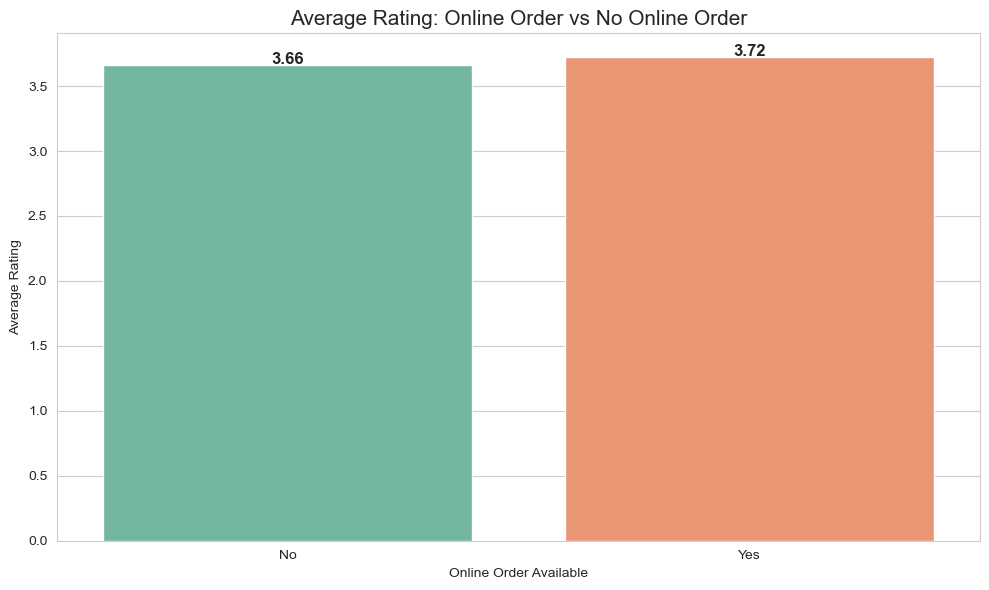

In [81]:
#INSIGHT VISUALIZATION
# Visual summary of online order vs rating
plt.figure(figsize=(10, 6))
online_rating = df.groupby('online_order')['rate'].mean().round(2)
sns.barplot(x=online_rating.index, y=online_rating.values, palette='Set2')
plt.title('Average Rating: Online Order vs No Online Order', fontsize=15)
plt.xlabel('Online Order Available')
plt.ylabel('Average Rating')

# Adding value labels on bars
for i, v in enumerate(online_rating.values):
    plt.text(i, v + 0.01, str(v), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('images/insight_online_order.png')
plt.show()

C:\Users\Acer\AppData\Local\Temp\ipykernel_6216\756581889.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=cost_order,


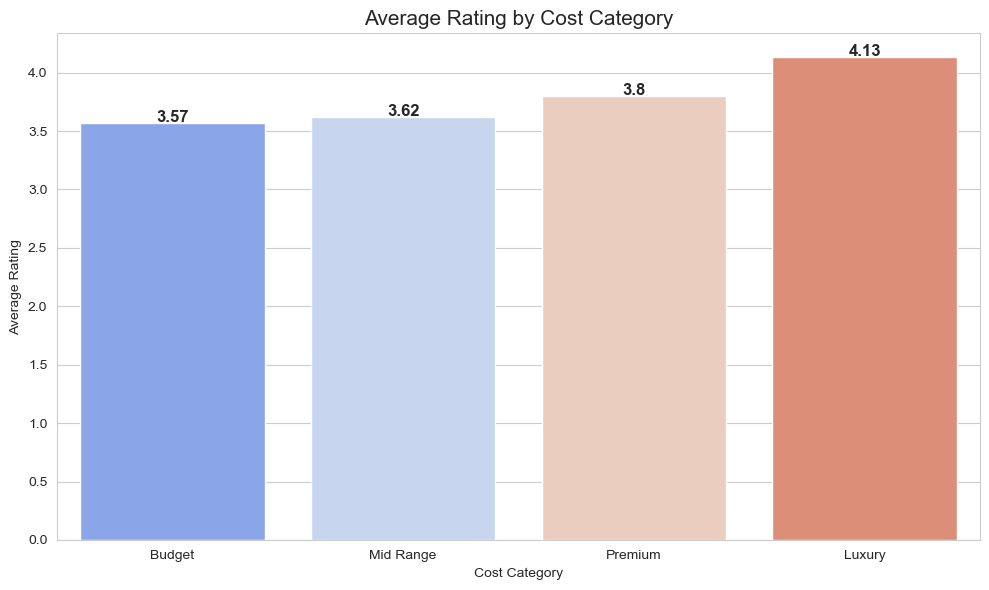

In [82]:
# Visual summary of cost category vs rating
cost_order = ['Budget', 'Mid Range', 'Premium', 'Luxury']
cost_rating = df.groupby('cost_category')['rate'].mean().round(2)

plt.figure(figsize=(10, 6))
bars = sns.barplot(x=cost_order, 
                   y=[cost_rating[c] for c in cost_order], 
                   palette='coolwarm')
plt.title('Average Rating by Cost Category', fontsize=15)
plt.xlabel('Cost Category')
plt.ylabel('Average Rating')

# Adding value labels on bars
for i, v in enumerate([cost_rating[c] for c in cost_order]):
    plt.text(i, v + 0.01, str(v), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('images/insight_cost_rating.png')
plt.show()

C:\Users\Acer\AppData\Local\Temp\ipykernel_6216\457980806.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_rated_locations.values,


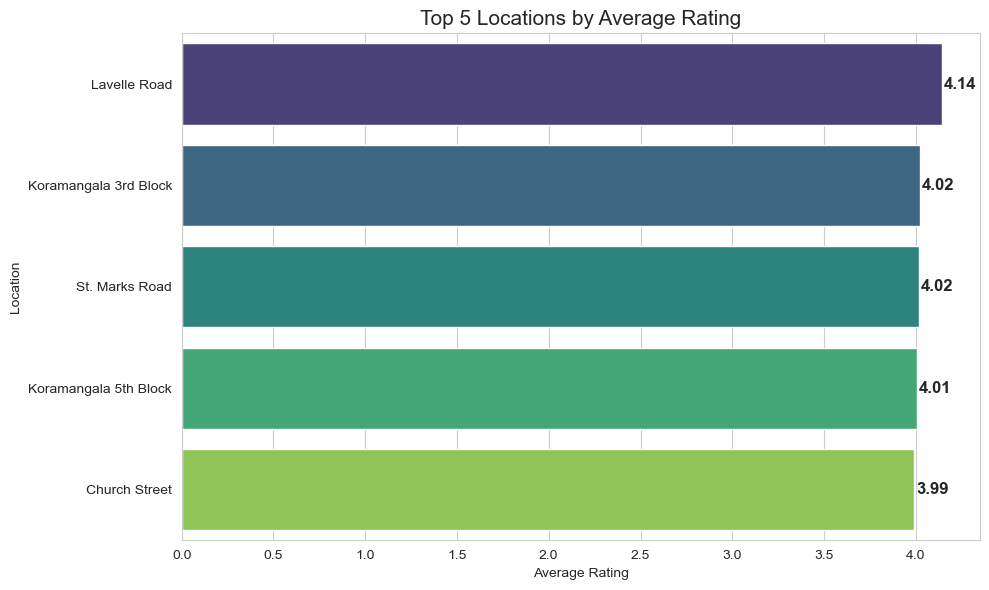

In [83]:
# Which locations have best average ratings?
top_rated_locations = df.groupby('location')['rate'].mean().sort_values(ascending=False).head(5)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_rated_locations.values, 
            y=top_rated_locations.index, 
            palette='viridis')
plt.title('Top 5 Locations by Average Rating', fontsize=15)
plt.xlabel('Average Rating')
plt.ylabel('Location')

# Adding value labels
for i, v in enumerate(top_rated_locations.values):
    plt.text(v + 0.01, i, str(round(v, 2)), va='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('images/insight_top_locations.png')
plt.show()

In [84]:
print("""
=================================================
     BUSINESS RECOMMENDATIONS
=================================================

FOR RESTAURANT OWNERS:

1. ENABLE ONLINE ORDERING:
   - Data shows restaurants with online ordering 
     get better ratings.
   - If not already available, enable online 
     ordering to improve visibility and ratings.

2. CONSIDER TABLE BOOKING:
   - Restaurants with table booking have 
     significantly higher ratings.
   - Adding this feature improves customer 
     experience and perceived quality.

3. FOCUS ON NORTH INDIAN / CHINESE CUISINE:
   - These are the most popular cuisines.
   - New restaurants should consider these 
     cuisines for maximum customer reach.

4. LOCATION STRATEGY:
   - BTM and Koramangala have most competition.
   - New restaurants could target less crowded 
     but popular areas to stand out.

5. PRICING STRATEGY:
   - Premium and Luxury restaurants get better 
     ratings but there are fewer of them.
   - Mid Range restaurants have the best 
     balance of volume and ratings.

FOR ZOMATO PLATFORM:

6. PROMOTE ONLINE ORDERING:
   - Encourage more restaurants to enable 
     online ordering as it correlates with 
     better ratings and customer satisfaction.

7. TARGET BUDGET SEGMENT:
   - Most restaurants are Budget/Mid Range.
   - Zomato should focus marketing efforts 
     on this segment as it has highest volume.

=================================================
""")


     BUSINESS RECOMMENDATIONS

FOR RESTAURANT OWNERS:

1. ENABLE ONLINE ORDERING:
   - Data shows restaurants with online ordering 
     get better ratings.
   - If not already available, enable online 
     ordering to improve visibility and ratings.

2. CONSIDER TABLE BOOKING:
   - Restaurants with table booking have 
     significantly higher ratings.
   - Adding this feature improves customer 
     experience and perceived quality.

3. FOCUS ON NORTH INDIAN / CHINESE CUISINE:
   - These are the most popular cuisines.
   - New restaurants should consider these 
     cuisines for maximum customer reach.

4. LOCATION STRATEGY:
   - BTM and Koramangala have most competition.
   - New restaurants could target less crowded 
     but popular areas to stand out.

5. PRICING STRATEGY:
   - Premium and Luxury restaurants get better 
     ratings but there are fewer of them.
   - Mid Range restaurants have the best 
     balance of volume and ratings.

FOR ZOMATO PLATFORM:

6. PROMOTE ONLINE

In [85]:
# Final summary of the entire analysis
print("=" * 50)
print("FINAL SUMMARY - ZOMATO DATA ANALYSIS")
print("=" * 50)
print(f"Total Restaurants Analyzed: {len(df)}")
print(f"Total Locations Covered: {df['location'].nunique()}")
print(f"Total Cuisine Types: {df['cuisines'].nunique()}")
print(f"Average Rating: {df['rate'].mean().round(2)}")
print(f"Average Cost for Two: ₹{df['cost_for_two'].mean().round(2)}")
print(f"Restaurants with Online Order: {df[df['online_order']=='Yes'].shape[0]}")
print(f"Restaurants with Table Booking: {df[df['book_table']=='Yes'].shape[0]}")
print("=" * 50)

FINAL SUMMARY - ZOMATO DATA ANALYSIS
Total Restaurants Analyzed: 41665
Total Locations Covered: 92
Total Cuisine Types: 2384
Average Rating: 3.7
Average Cost for Two: ₹602.66
Restaurants with Online Order: 27206
Restaurants with Table Booking: 6304


In [91]:
# Final summary of the entire analysis
print("=" * 50)
print("FINAL SUMMARY - ZOMATO DATA ANALYSIS")
print("=" * 50)
print("Total Restaurants Analyzed:", len(df))
print("Total Locations Covered:", df['location'].nunique())
print("Total Cuisine Types:", df['cuisines'].nunique())
print("Average Rating:", round(df['rate'].mean(), 2))
print("Average Cost for Two:", round(df['cost_for_two'].mean(), 2))

online_count = df[df['online_order'] == 'Yes'].shape[0]
booking_count = df[df['book_table'] == 'Yes'].shape[0]

print("Restaurants with Online Order:", online_count)
print("Restaurants with Table Booking:", booking_count)
print("=" * 50)

FINAL SUMMARY - ZOMATO DATA ANALYSIS
Total Restaurants Analyzed: 41665
Total Locations Covered: 92
Total Cuisine Types: 2384
Average Rating: 3.7
Average Cost for Two: 602.66
Restaurants with Online Order: 27206
Restaurants with Table Booking: 6304


CONCLUSION

In [92]:
print("""
=================================================
         CONCLUSION - ZOMATO DATA ANALYSIS
=================================================

In this project, I analyzed the Zomato Bangalore 
restaurant dataset which contained information 
about 45,000+ restaurants across 93 locations 
in Bangalore, India.

WHAT I DID:
- Cleaned and preprocessed the raw dataset
- Handled missing values appropriately
- Performed Exploratory Data Analysis (EDA)
- Created meaningful visualizations
- Performed statistical analysis
- Created new features (cost and rating categories)
- Derived business insights and recommendations

WHAT I FOUND:
- Average restaurant rating in Bangalore is 3.72
- Restaurants with online ordering get better ratings
- Table booking restaurants have higher ratings
- North Indian and Chinese are most popular cuisines
- BTM and Koramangala have most restaurants
- Sankey Road is the most expensive location
- Most restaurants are Budget or Mid Range category
- Higher cost restaurants tend to get better ratings

WHAT THIS MEANS:
- Online ordering and table booking are important 
  features for restaurant success
- Location and pricing strategy matter a lot
- Budget and Mid Range segment dominates 
  Bangalore's food scene

This project helped me understand the complete 
data analytics workflow — from raw data to 
meaningful business insights — using Python, 
Pandas, Matplotlib and Seaborn.

=================================================
""")


         CONCLUSION - ZOMATO DATA ANALYSIS

In this project, I analyzed the Zomato Bangalore 
restaurant dataset which contained information 
about 45,000+ restaurants across 93 locations 
in Bangalore, India.

WHAT I DID:
- Cleaned and preprocessed the raw dataset
- Handled missing values appropriately
- Performed Exploratory Data Analysis (EDA)
- Created meaningful visualizations
- Performed statistical analysis
- Created new features (cost and rating categories)
- Derived business insights and recommendations

WHAT I FOUND:
- Average restaurant rating in Bangalore is 3.72
- Restaurants with online ordering get better ratings
- Table booking restaurants have higher ratings
- North Indian and Chinese are most popular cuisines
- BTM and Koramangala have most restaurants
- Sankey Road is the most expensive location
- Most restaurants are Budget or Mid Range category
- Higher cost restaurants tend to get better ratings

WHAT THIS MEANS:
- Online ordering and table booking are important 

In [93]:
# Final look at our cleaned and enriched dataset
print("Final Dataset Shape:", df.shape)
print("\nFinal Columns:")
print(df.columns.tolist())
print("\nFirst 5 rows of final dataset:")
df.head()

Final Dataset Shape: (41665, 13)

Final Columns:
['name', 'online_order', 'book_table', 'rate', 'votes', 'location', 'rest_type', 'cuisines', 'cost_for_two', 'listed_in(type)', 'listed_in(city)', 'cost_category', 'rating_category']

First 5 rows of final dataset:


,name,online_order,book_table,rate,votes,location,rest_type,cuisines,cost_for_two,listed_in(type),listed_in(city),cost_category,rating_category
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,Buffet,Banashankari,Premium,Very Good
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0,Buffet,Banashankari,Premium,Very Good
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800.0,Buffet,Banashankari,Premium,Good
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,Buffet,Banashankari,Budget,Good
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,Buffet,Banashankari,Mid Range,Good


In [95]:
# Saving the final cleaned dataset
df.to_csv('zomato_cleaned.csv', index=False)
print("Cleaned dataset saved successfully!")
print("Location: data/zomato_cleaned.csv")

Cleaned dataset saved successfully!
Location: data/zomato_cleaned.csv
